In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data.dataloader as dataloader

In [3]:
from torchvision import transforms
from torchvision.datasets import MNIST
import torchvision

In [43]:
from tqdm import tqdm, trange
import numpy as np
import matplotlib.pyplot as plt
import time
%matplotlib inline

In [35]:
batch_size = 64

train = MNIST("./data", train=True, download=True, transform=transforms.ToTensor())
test = MNIST("./data", train=False, download=True, transform=transforms.ToTensor())

train_dataloader = dataloader.DataLoader(train, shuffle=True, batch_size=batch_size, num_workers=0, pin_memory=True)
test_dataloader = dataloader.DataLoader(test, shuffle=False, batch_size=batch_size, num_workers=0, pin_memory=True)

In [36]:
images, labels = next(iter(train_dataloader))
print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

Images shape: torch.Size([64, 1, 28, 28])
Labels shape: torch.Size([64])


In [37]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


We can see that (as specified) our mini-batch is 64. The dataloader has passed us a 4D Tensor as input data, the first dimension (d0) is known as the "batch
dimension" (B) the other three are the image dimensions (CxHxW). We can this of this 4D Tensor as a stack of 64, 1 channel, 28x28 images.
The image labels are a 1D Tensor, 1 single scalar value per image (per mini-batch "instance").

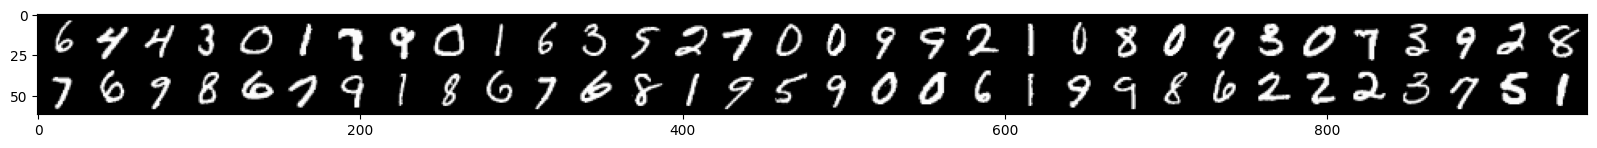

In [38]:
# visualize a few images

plt.figure(figsize=(20, 10))
out = torchvision.utils.make_grid(images, 32)
plt.imshow(out.numpy().transpose(1, 2, 0))

In [50]:
class SimpleMLP(nn.Module):
    def __init__(self, num_classes):
        super(SimpleMLP, self).__init__()

        self.fc1 = nn.Linear(28*28, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, num_classes)
    
    def forward(self, x):
        # The passed data is a batch of single channel image.
        # with shape BSx1x28x28. We need to flatten it to BSx784
        #x = x.view(x.size(0), -1)
        x = x.reshape(x.size(0), -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

In [51]:
model = SimpleMLP(num_classes=10).to(device)
criterion = nn.CrossEntropyLoss()
lr = 1e-3
optimizer = optim.Adam(model.parameters(), lr=lr)

epochs = 20

print(model)

SimpleMLP(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=10, bias=True)
)


In [52]:
def train_epoch(model, train_loader, criterion, optimizer, loss_logger):
    for batch_idx, (data, target) in enumerate(tqdm(train_loader, desc="Training", leave=False)):
        outputs = model(data.to(device))
        loss = criterion(outputs, target.to(device))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_logger.append(loss.item())

    return model, optimizer, loss_logger

In [53]:
def test_model(model, test_loader, criterion, loss_logger):
    with torch.no_grad():
        correct_pred = 0
        total_pred = 0
        for batch_idx, (data, target) in enumerate(tqdm(test_loader, desc="Testing", leave=False)):
            outputs = model(data.to(device))
            
            # calculate the accuracy of the model
            _, predicted = torch.max(outputs, 1)
            correct_pred += (predicted == target.to(device)).sum().item()
            total_pred += target.shape[0]

            # calculate the loss
            loss = criterion(outputs, target.to(device))
            loss_logger.append(loss.item())
        
    acc = (correct_pred / total_pred) * 100.0
    return loss_logger, acc

In [54]:
train_loss = []
test_loss = []
test_acc = []

In [55]:
for i in trange(epochs, desc="Epochs", leave=False):
    model, optimizer, train_loss = train_epoch(model, train_dataloader, criterion, optimizer, train_loss)
    test_loss, acc = test_model(model, test_dataloader, criterion, test_loss)
    test_acc.append(acc)

print("Final accuracy is: ", acc)

Final accuracy is:  98.42


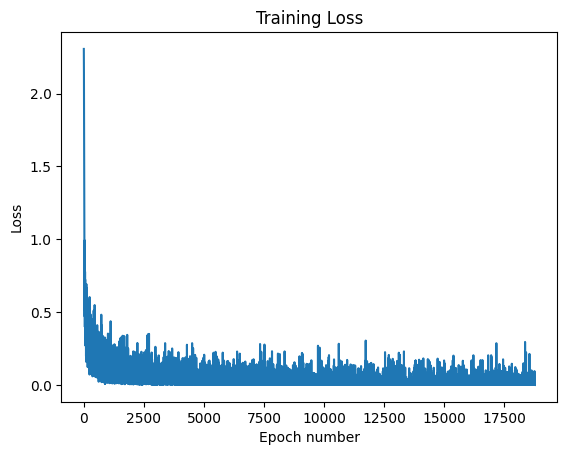

In [56]:
plt.title("Training Loss")
plt.xlabel("Epoch number")
plt.ylabel("Loss")
plt.plot(train_loss)

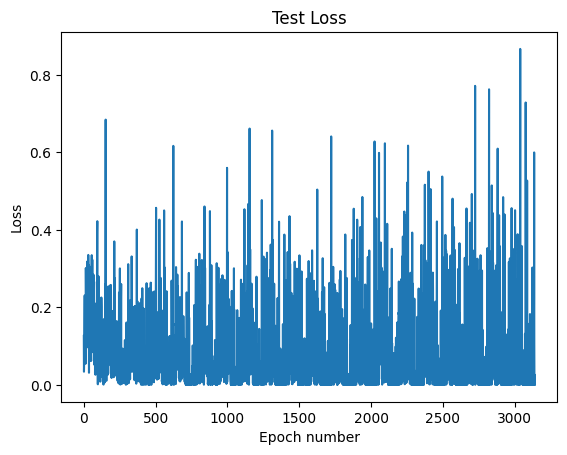

In [57]:
plt.title("Test Loss")
plt.xlabel("Epoch number")
plt.ylabel("Loss")
plt.plot(test_loss)

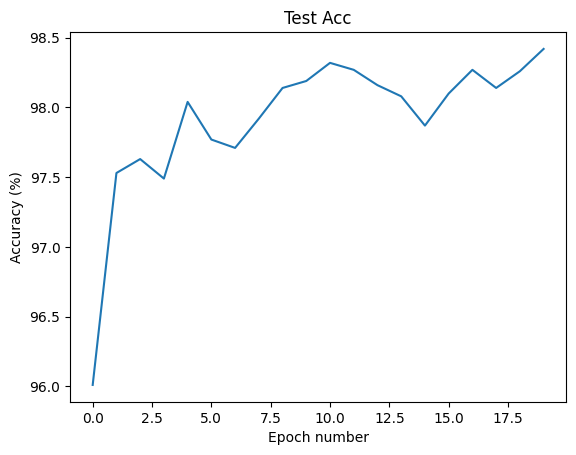

In [58]:
plt.title("Test Acc")
plt.xlabel("Epoch number")
plt.ylabel("Accuracy (%)")
plt.plot(test_acc)

In [59]:
x = model(images.to(device))
print(x)

tensor([[ -5.2500, -13.3723, -15.8646, -27.1042, -11.8873,  -6.6417,  22.4431,
         -47.8257,  -9.8457, -17.7715],
        [-17.1894, -13.4224,  -9.3768, -18.1159,  22.5284, -12.6225, -11.8151,
         -11.2854, -10.5496,  -1.3201],
        [-16.4651, -11.1218,  -4.3444, -22.5518,  22.7127, -11.8101,  -9.2800,
         -15.2843, -10.0675,  -9.3716],
        [-16.0670,  -5.6753,  -2.2232,  12.1429, -13.6883,  -7.0537, -17.4499,
          -4.7022,  -7.5958,  -7.7639],
        [ 32.5575, -14.5003, -16.6778, -31.3828, -29.3134, -28.1772,  -5.9580,
         -18.4042, -25.3456, -22.0064],
        [-15.1971,  21.7423,  -5.4087, -31.5901,  -5.8933, -20.8389,  -6.6660,
          -5.7533,  -7.0475, -13.3818],
        [-21.0218,  -4.4750,  -1.2278,   1.4228,  -8.3053, -15.1693, -34.8862,
          17.7681, -19.0952,   0.4439],
        [ -4.7025,  -7.9363,  -8.1669,  -7.4014,  -2.6575,  -6.3190, -12.0530,
          -5.2200,  -1.4149,  11.9897],
        [ 25.7371, -13.6163, -15.2826, -23.0655,

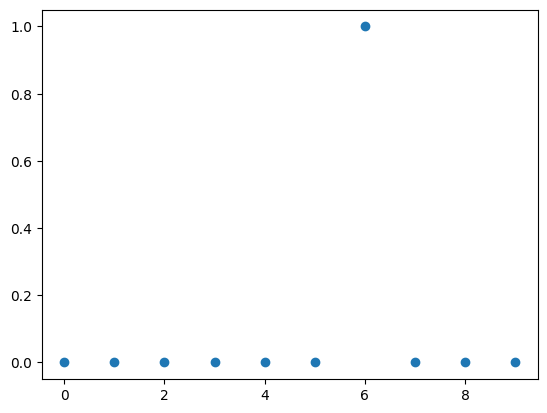

: 

In [ ]:
plt.scatter(np.arange(10), F.softmax(x, 1)[0].detach().cpu().numpy())